In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


In [62]:
m = 1200
tenure   = np.random.randint(1, 72, m)           # місяців з нами
monthly  = np.random.normal(70, 25, m).clip(15, 150)  # щомісячна оплата, $
support  = np.random.poisson(1.5, m)             # звернень у підтримку за рік
age      = np.random.randint(18, 75, m)          # вік клієнта

# Прихована логіка ризику відтоку (модель її не знає):
risk = (
    -0.05 * tenure        # довше з нами → менший ризик
    + 0.02 * monthly      # дорожчий тариф → трохи більший ризик
    + 0.45 * support      # багато звернень у підтримку → більший ризик
    - 0.01 * age          # старші клієнти трохи лояльніші
    + np.random.normal(0, 0.7, m)
)
prob = 1 / (1 + np.exp(-(risk - 0.5)))   # перетворюємо ризик на ймовірність 0..1
churn = (np.random.rand(m) < prob).astype(int)

df = pd.DataFrame({
    "tenure": tenure, "monthly": monthly.round(1),
    "support": support, "age": age, "churn": churn,
})

print("Частка клієнтів, що пішли:", f"{df['churn'].mean():.1%}")
df.head()

Частка клієнтів, що пішли: 39.3%


,tenure,monthly,support,age,churn
0,52,21.7,1,21,0
1,15,39.8,1,20,0
2,61,43.2,4,73,0
3,21,87.1,0,46,1
4,24,65.9,1,69,1


In [63]:
from sklearn.model_selection import train_test_split

# X = df[['tenure', 'monthly', 'support', 'age']]  # features - ознаки
X = df[['support']]  # features - ознаки
# X = df[['tenure']]  # features - ознаки
y = df['churn']  # target - ціль

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Навчальна вибірка:", X_train.shape[0], "клієнтів")
print("Тестова вибірка:", X_test.shape[0], "клієнтів")

Навчальна вибірка: 960 клієнтів
Тестова вибірка: 240 клієнтів


# Decision Tree

In [64]:
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE
)

model_tree.fit(X_train, y_train)
y_pred = model_tree.predict(X_test)

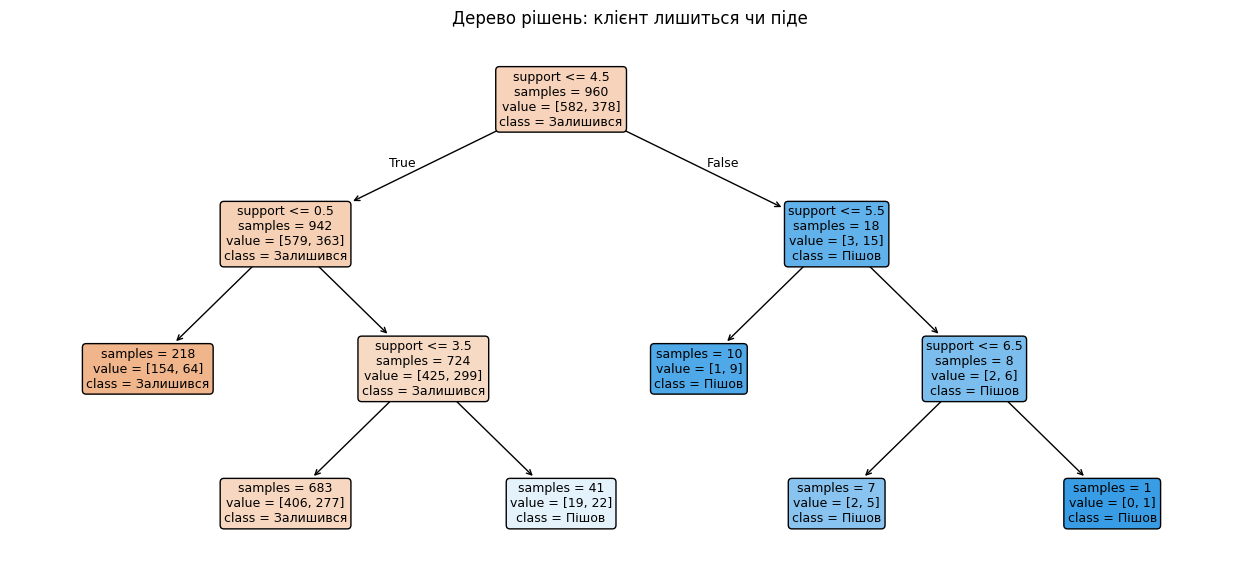

In [65]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 7))
plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=['Залишився', 'Пішов'],
    filled=True, rounded=True, fontsize=9, impurity=False
)

plt.title("Дерево рішень: клієнт лишиться чи піде")
plt.show()

In [66]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy = {acc:.2%}\n")

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(
    cm,
    index=["Насправді залишилися", "Насправді пішли"],
    columns=["Передбачено залишилися", "Передбачено пішли"]
)

print("Матриця плутанини:")
display(df_cm)
# print(df_cm)

print("\nДетальний звіт:")
print(classification_report(y_test, y_pred, target_names=["Залишилися", "Пішли"]))

Accuracy = 62.50%

Матриця плутанини:


,Передбачено залишилися,Передбачено пішли
Насправді залишилися,142,4
Насправді пішли,86,8



Детальний звіт:
              precision    recall  f1-score   support

  Залишилися       0.62      0.97      0.76       146
       Пішли       0.67      0.09      0.15        94

    accuracy                           0.62       240
   macro avg       0.64      0.53      0.46       240
weighted avg       0.64      0.62      0.52       240



# Random Forest

In [67]:
# from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

model_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=RANDOM_STATE
)

model_forest.fit(X_train, y_train)
y_pred_rf = model_forest.predict(X_test)

print(f"Одне дерево: accuracy = {accuracy_score(y_test, y_pred):.2%}")
print(f"Цілий ліс: accuracy = {accuracy_score(y_test, y_pred_rf):.2%}")

Одне дерево: accuracy = 62.50%
Цілий ліс: accuracy = 62.50%


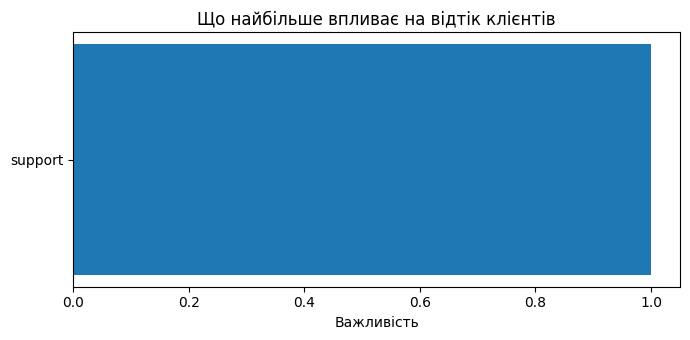

,features,importances
0,support,1.0


In [68]:
importances = pd.DataFrame({
    "features": X.columns,
    "importances": model_forest.feature_importances_.round(3)
}).sort_values("importances", ascending=True)

plt.figure(figsize=(7, 3.5))
plt.barh(importances["features"], importances["importances"])

plt.xlabel("Важливість")
plt.title("Що найбільше впливає на відтік клієнтів")
plt.tight_layout()
plt.show()

importances